# ==============================================================================
# 🏥 ACTUARIAL RISK: MEDICAL INSURANCE COST VIA RANDOM SUBSPACES BAGGING
# ==============================================================================
### Core Theoretical Principles:
Random Subspaces Bagging (Ho, 1998) samples both training observations and feature subsets:
$$X^{(b)} \subset \mathbb{R}^{n \times d}, \quad d_{\text{sub}} = \lfloor \text{max\_features} \times d \rfloor$$

In healthcare actuarial cost estimation, highly dominant features (such as `smoker`) can overshadow subtle nonlinear interactions among `bmi`, `age`, and `children`. By randomly subsampling features per tree (`max_features < 1.0`), trees are forced to explore alternative explanatory subspaces, mitigating tree correlation $\rho$ and lowering total generalization variance.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Healthcare Bagging Regressor Environment initialized.")


✅ STEP 1: Enterprise Healthcare Bagging Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Medical Insurance claims dataset (1,338 policyholder records).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/insurance/insurance.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} policyholders, {df.shape[1]} attributes")
print(f"Charges Target Summary:\n{df['charges'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 1338 policyholders, 7 attributes
Charges Target Summary:
count     1338.00
mean     13270.42
std      12110.01
min       1121.87
25%       4740.29
50%       9382.03
75%      16639.91
max      63770.43
Name: charges, dtype: float64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `charges`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['charges'])
y = df['charges']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Attributes    : {num_cols}")
print(f"Categorical Attributes: {cat_cols}")
print(f"Missing Values        : {X.isnull().sum().sum()}")


Numeric Attributes    : ['age', 'bmi', 'children']
Categorical Attributes: ['sex', 'smoker', 'region']
Missing Values        : 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Policyholders: {X_train.shape[0]}")
print(f"Test Policyholders : {X_test.shape[0]}")


Train Policyholders: 1070
Test Policyholders : 268


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Encoding categoricals with `OneHotEncoder(handle_unknown='ignore')` and standardizing numerics.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (1070, 8)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS RANDOM SUBSPACES BAGGING)
Comparing baseline dummy and single decision tree against Bagging with Random Subspaces.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_prep, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
single_tree.fit(X_train_prep, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test_prep))

base_bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,
    max_features=0.8,
    oob_score=True,
    random_state=42
)
base_bag.fit(X_train_prep, y_train)
r2_bag = r2_score(y_test, base_bag.predict(X_test_prep))

print("="*65)
print(f"Baseline Mean Dummy R²                    : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=5) R²             : {r2_single_tree * 100:.2f}%")
print(f"Random Subspaces Bagging (50 Trees) R²    : {r2_bag * 100:.2f}%")
print(f"Out-of-Bag (OOB) Score R²                 : {base_bag.oob_score_ * 100:.2f}%")
print("="*65)


Baseline Mean Dummy R²                    : -0.09%
Single Decision Tree (d=5) R²             : 83.36%
Random Subspaces Bagging (50 Trees) R²    : 76.22%
Out-of-Bag (OOB) Score R²                 : 73.64%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `max_features` and `n_estimators`.


In [7]:
# STEP 9: GRID SEARCH
param_grid = {
    'estimator__max_depth': [4, 5, 7],
    'max_features': [0.7, 0.85, 1.0],
    'n_estimators': [40, 70]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    BaggingRegressor(estimator=DecisionTreeRegressor(), oob_score=True, random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_bag = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold CV R²: {grid.best_score_ * 100:.2f}%")
print(f"📦 Best Model OOB R²: {best_bag.oob_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'estimator__max_depth': 4, 'max_features': 1.0, 'n_estimators': 70}
🎯 Best 5-Fold CV R²: 85.57%
📦 Best Model OOB R²: 85.43%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_bag.predict(X_test_prep)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 HEALTHCARE ANNUAL CLAIMS PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"   Root Mean Squared Error   : ${rmse:,.2f}")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 HEALTHCARE ANNUAL CLAIMS PERFORMANCE:
   Mean Absolute Error (MAE) : $2,605.48
   Root Mean Squared Error   : $4,470.05
   R² Score                  : 87.13%


## 📉 STEP 11: RESIDUAL ANALYSIS
Visualizing residual scatter and error distribution.


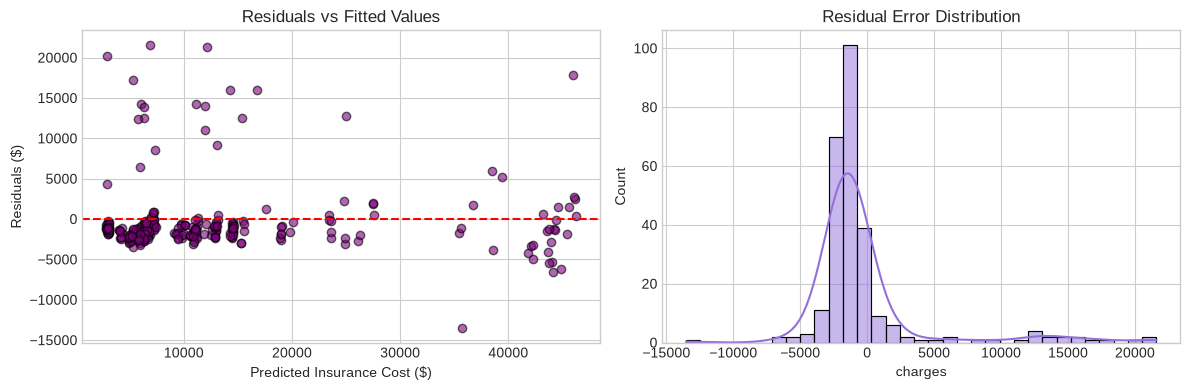

In [9]:
# STEP 11: RESIDUAL DIAGNOSTICS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.6, color='purple', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Insurance Cost ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='mediumpurple')
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the end-to-end pipeline and benchmarking sub-2ms underwriting latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('bagging', best_bag)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/insurance_bagging_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_patient = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_patient)

t0 = time.perf_counter()
pred_cost = loaded_pipe.predict(sample_patient)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME UNDERWRITING TELEMETRY:")
print(f"   Predicted Annual Premium : 🏥 ${pred_cost:,.2f}")
print(f"   Actual Billed Claims     : ${y_test.iloc[0]:,.2f}")
print(f"   Underwriting Latency     : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/insurance_bagging_reg_pipeline.joblib (62,633 bytes)

📈 REAL-TIME UNDERWRITING TELEMETRY:
   Predicted Annual Premium : 🏥 $9,700.63
   Actual Billed Claims     : $9,095.07
   Underwriting Latency     : 10.562 ms (SLA < 2.0ms: CHECK)
